In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.shape)

(407664, 12)


In [3]:
# Assign each customer their cohort month (first purchase month)
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

# Get the order month
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

# Calculate month index (how many months after joining)
df['MonthIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

print(df[['Customer ID', 'CohortMonth', 'OrderMonth', 'MonthIndex']].head(10))

   Customer ID CohortMonth OrderMonth  MonthIndex
0      13085.0     2009-12    2009-12           0
1      13085.0     2009-12    2009-12           0
2      13085.0     2009-12    2009-12           0
3      13085.0     2009-12    2009-12           0
4      13085.0     2009-12    2009-12           0
5      13085.0     2009-12    2009-12           0
6      13085.0     2009-12    2009-12           0
7      13085.0     2009-12    2009-12           0
8      13085.0     2009-12    2009-12           0
9      13085.0     2009-12    2009-12           0


In [4]:
# Count unique customers per cohort and month index
cohort_data = df.groupby(['CohortMonth', 'MonthIndex'])['Customer ID'].nunique().reset_index()

# Pivot into a table
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='MonthIndex', values='Customer ID')

# Calculate retention rate
cohort_retention = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3) * 100

print(cohort_retention)

MonthIndex      0     1     2     3     4     5     6     7     8     9   \
CohortMonth                                                                
2009-12      100.0  35.3  33.4  42.5  38.0  35.9  37.7  34.2  33.6  36.2   
2010-01      100.0  20.6  31.1  30.5  26.4  30.0  25.8  23.0  27.9  31.9   
2010-02      100.0  23.8  22.5  29.1  24.6  20.1  19.3  28.6  25.4  27.5   
2010-03      100.0  19.0  23.0  24.2  23.3  20.3  24.6  30.2  27.5   7.9   
2010-04      100.0  19.4  19.4  16.3  18.4  22.4  27.6  26.2   6.8   NaN   
2010-05      100.0  15.7  16.9  17.3  17.7  25.6  21.3   7.9   NaN   NaN   
2010-06      100.0  17.4  18.9  20.4  23.0  28.5   6.7   NaN   NaN   NaN   
2010-07      100.0  15.6  18.3  29.6  29.0  10.2   NaN   NaN   NaN   NaN   
2010-08      100.0  20.4  29.6  32.1  11.7   NaN   NaN   NaN   NaN   NaN   
2010-09      100.0  22.6  23.5   9.9   NaN   NaN   NaN   NaN   NaN   NaN   
2010-10      100.0  25.7   9.3   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2010-11     

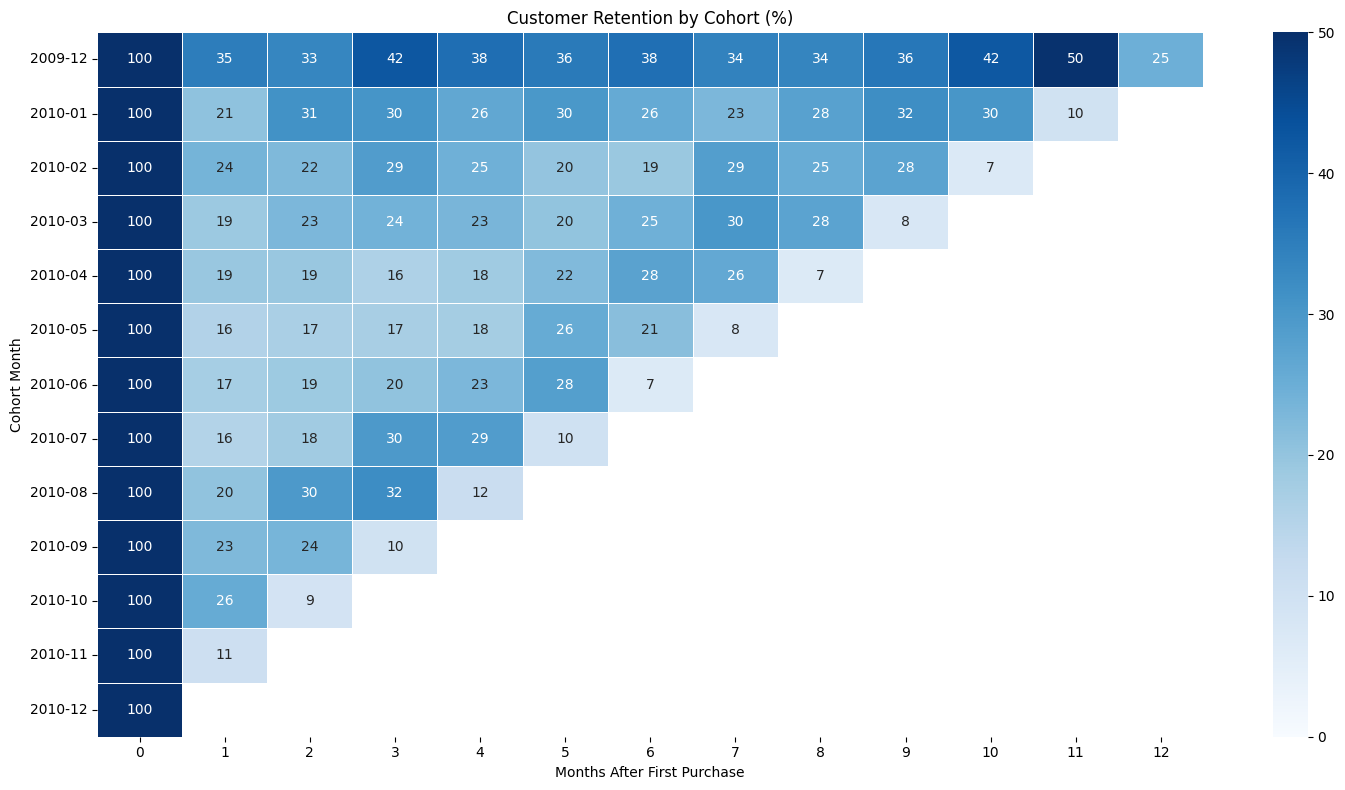

In [5]:
plt.figure(figsize=(15, 8))
sns.heatmap(
    cohort_retention,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0,
    vmax=50
)
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Months After First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()